# BizNess SME Survival & Profit Prediction — Model Pipeline v2

**Goal:** Predict whether a Cameroonian SME will survive 3 years, and forecast its monthly profit.

**Target Accuracy:** ≥ 80% on the survival classifier.

## Key Fixes Over v1
- Centralized preprocessor builder (no copy-paste)
- Cross-validation on every model before declaring a winner
- RandomizedSearchCV hyperparameter tuning on the best model
- Feature engineering validated — only kept if it actually improves the score
- SMOTE used consistently for all classifiers (accuracy-focused)
- Threshold analysis runs on the final saved model
- Logger uses utf-8 encoding (fixes emoji crash on Windows)

---

## Section 1 — Imports & Global Setup

In [46]:
# ============================================================
# STANDARD LIBRARY
# ============================================================
import os
import logging
import warnings
import joblib

# ============================================================
# DATA MANIPULATION
# ============================================================
import pandas as pd
import numpy as np

# ============================================================
# VISUALISATION
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# ============================================================
# SKLEARN — PREPROCESSING & SPLITTING
# ============================================================
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,       # Scores a model across multiple CV folds
    StratifiedKFold,       # Keeps class ratio intact across every fold
    RandomizedSearchCV     # Faster than GridSearchCV for large param spaces
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ============================================================
# IMBALANCED-LEARN — SMOTE
# ============================================================
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # Supports SMOTE inside a pipeline

# ============================================================
# CLASSIFICATION MODELS
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# ============================================================
# REGRESSION MODELS
# ============================================================
from xgboost import XGBRegressor

# ============================================================
# EVALUATION METRICS
# ============================================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    r2_score,
    mean_absolute_error
)

# ============================================================
# GLOBAL SETTINGS
# ============================================================
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Single seed used everywhere — guarantees reproducible results
RANDOM_SEED = 42

# Cross-validation strategy: 5 folds, keeps class ratio balanced in each fold
CV_STRATEGY = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

print('All packages imported successfully.')

All packages imported successfully.


## Section 2 — Logging Setup

In [47]:
# Create the logs directory if it doesn't already exist
os.makedirs('logs', exist_ok=True)

# FIX (v1 bug): The original logger crashed on Windows because the file
# handler defaulted to cp1252 encoding, which cannot handle emoji characters.
# Solution: force utf-8 encoding on the file handler.
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('logs/bizness_model_v2.log', encoding='utf-8'),  # utf-8 fixes emoji crash
        logging.StreamHandler()
    ]
)

logger = logging.getLogger('BizNess_ML_v2')
logger.info('BizNess ML Pipeline v2 — Logging initialised successfully.')

2026-04-22 01:14:02,558 - INFO - BizNess ML Pipeline v2 — Logging initialised successfully.


## Section 3 — Reusable Helper Functions

All repeated logic lives here so no code is copy-pasted across cells.

In [48]:
def build_preprocessor(numerical_cols, categorical_cols):
    """
    Build a ColumnTransformer that:
      - Fills missing numbers with the median, then scales to mean=0, std=1
      - Fills missing text with 'Unknown', then one-hot encodes

    Centralising this avoids copy-pasting the same block three times
    and ensures all models use identical preprocessing.
    """
    # Pipeline for numeric columns
    numeric_pipeline = Pipeline(steps=[
        ('fill_missing', SimpleImputer(strategy='median')),
        ('scale',        StandardScaler())
    ])

    # Pipeline for categorical (text) columns
    categorical_pipeline = Pipeline(steps=[
        ('fill_missing', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('encode',       OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ('numeric',      numeric_pipeline,      numerical_cols),
        ('categorical',  categorical_pipeline,  categorical_cols)
    ])

    return preprocessor


def evaluate_classifier(pipeline, X_test, y_test, model_name, cmap='Blues'):
    """
    Run predictions, print a classification report, and draw a confusion matrix.
    Returns a dict of the key metrics for easy comparison later.
    """
    predictions = pipeline.predict(X_test)

    accuracy  = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, average='macro')
    recall    = recall_score(y_test, predictions, average='macro')
    f1        = f1_score(y_test, predictions, average='macro')

    print(f'\n{"="*55}')
    print(f'  RESULTS: {model_name}')
    print(f'{"="*55}')
    print(f'  Accuracy  : {accuracy  * 100:.2f}%')
    print(f'  Precision : {precision * 100:.2f}%')
    print(f'  Recall    : {recall    * 100:.2f}%')
    print(f'  F1-Score  : {f1        * 100:.2f}%')
    print(f'{"-"*55}')
    print(classification_report(y_test, predictions, target_names=['Failed (0)', 'Survived (1)']))

    # Confusion matrix
    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap,
        xticklabels=['Predicted Failed', 'Predicted Survived'],
        yticklabels=['Actual Failed',    'Actual Survived']
    )
    plt.title(f'Confusion Matrix — {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {'model': model_name, 'accuracy': accuracy, 'precision': precision,
            'recall': recall, 'f1': f1}


def cross_validate_classifier(pipeline, X, y, model_name, cv=None):
    """
    Run 5-fold stratified cross-validation and print a summary.
    Returns the mean accuracy — used to rank models fairly.

    WHY: A single train/test split can be lucky or unlucky.
    CV gives us 5 separate estimates and averages them for a reliable score.

    NOTE: n_jobs=1 (single-threaded) is intentional — joblib's multiprocessing
    backend (loky) fails to serialize ImbPipeline objects on Python 3.14.
    The models' own internal parallelism (n_jobs=-1 on RF/LGBM/XGB) still works
    because those use threading, not multiprocessing.
    """
    if cv is None:
        cv = CV_STRATEGY

    print(f'  Running 5-fold CV for: {model_name} ...', end=' ', flush=True)

    # n_jobs=1 — do NOT change to -1, see docstring above
    cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy', n_jobs=1)

    mean_acc = cv_scores.mean()
    std_acc  = cv_scores.std()

    print(f'Done.  Mean Accuracy: {mean_acc * 100:.2f}% (+/- {std_acc * 100:.2f}%)')

    return mean_acc


print('Helper functions defined successfully.')

Helper functions defined successfully.


## Section 4 — Load & Inspect the Dataset

In [49]:
DATASET_PATH = 'BizNess_National_Training_Dataset_50k.csv'

try:
    raw_df = pd.read_csv(DATASET_PATH)
    logger.info(f'Dataset loaded — {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns')
    print(f'Dataset loaded: {raw_df.shape[0]:,} rows, {raw_df.shape[1]} columns')
except FileNotFoundError:
    logger.error(f'Dataset not found at path: {DATASET_PATH}')
    raise

raw_df.head()

2026-04-22 01:14:03,740 - INFO - Dataset loaded — 50,000 rows x 37 columns


Dataset loaded: 50,000 rows, 37 columns


,Business_ID,Region,Location,Urban_Rural,Sector,Business_Type,SME_Category_Cameroon,Startup_Capital_CFA,Employees,Monthly_Profit_CFA,...,Region_Growth_Rate,Region_Electricity_Index,Region_Infrastructure_Index,Region_Informal_Economy_Index,Region_Security_Index,Sector_Risk_Baseline,Sector_Capital_Intensity,Survival_Probability_Simulated,Risk_Level_Simulated,Survived_3_Years
0,1,West,Dschang,Rural,Education & Training,Education,Micro,12459454,1,282235,...,0.038,0.70,0.72,0.57,0.88,0.42,0.35,0.5578,Medium,0
1,2,Littoral,Manjo,Urban,Agriculture & Agro-processing,Agriculture,Micro,44991979,5,1106873,...,0.045,0.78,0.80,0.52,0.85,0.50,0.55,0.7333,Low,1
2,3,Littoral,Manjo,Rural,Education & Training,Education,Micro,20768165,3,645803,...,0.045,0.78,0.80,0.52,0.85,0.42,0.35,0.5976,Medium,1
3,4,Centre,Yaoundé,Urban,Education & Training,Education,Micro,29241786,4,776253,...,0.040,0.74,0.76,0.55,0.90,0.42,0.35,0.5560,Medium,1
4,5,North,Garoua,Urban,Healthcare,Healthcare,Micro,68451194,5,881644,...,0.028,0.58,0.60,0.62,0.78,0.40,0.55,0.5975,Medium,1


In [50]:
# Quick data audit before doing anything else
print('--- Column Types & Missing Values ---')
audit = pd.DataFrame({
    'dtype':        raw_df.dtypes,
    'missing':      raw_df.isnull().sum(),
    'missing_%':    (raw_df.isnull().sum() / len(raw_df) * 100).round(2),
    'unique_vals':  raw_df.nunique()
})
print(audit[audit['missing'] > 0])  # Only show columns that actually have missing values

print(f'\n--- Target Distribution ---')
target_counts = raw_df['Survived_3_Years'].value_counts()
target_pct    = raw_df['Survived_3_Years'].value_counts(normalize=True) * 100
print(f'  Survived (1): {target_counts[1]:,}  ({target_pct[1]:.1f}%)')
print(f'  Failed   (0): {target_counts[0]:,}  ({target_pct[0]:.1f}%)')

--- Column Types & Missing Values ---
                dtype  missing  missing_%  unique_vals
Owner_Education   str     3012       6.02            3

--- Target Distribution ---
  Survived (1): 33,543  (67.1%)
  Failed   (0): 16,457  (32.9%)


## Section 5 — Exploratory Data Analysis (EDA)

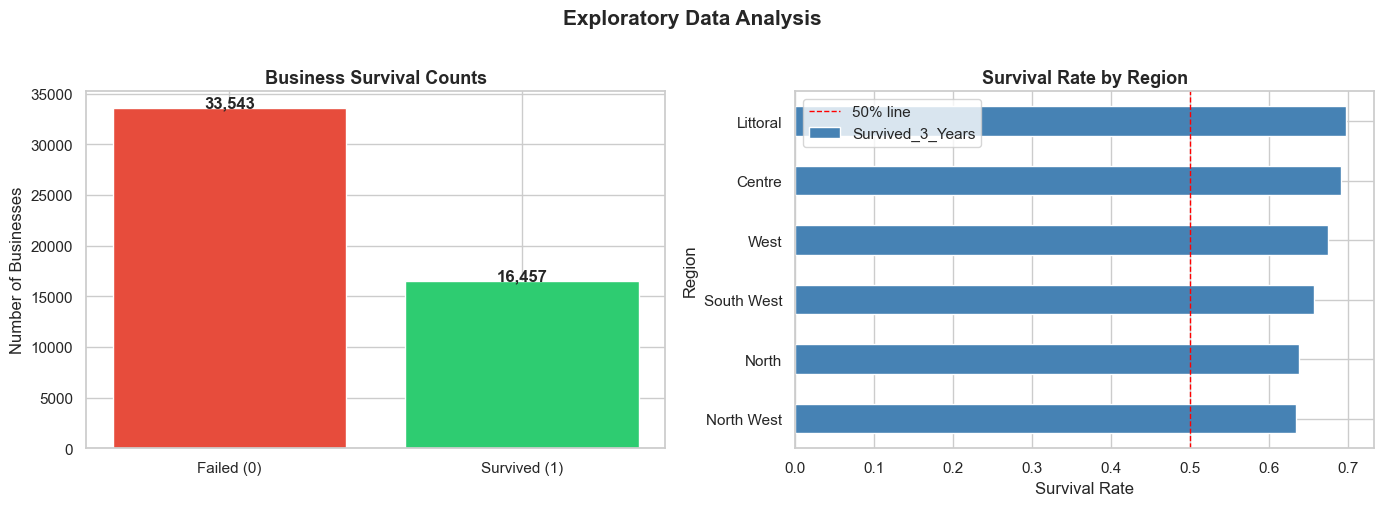

In [51]:
# --- Target Variable Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw counts
survival_counts = raw_df['Survived_3_Years'].value_counts()
axes[0].bar(['Failed (0)', 'Survived (1)'], survival_counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[0].set_title('Business Survival Counts', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Businesses')
for i, val in enumerate(survival_counts.values):
    axes[0].text(i, val + 100, f'{val:,}', ha='center', fontweight='bold')

# Right: survival rate by region
region_survival = raw_df.groupby('Region')['Survived_3_Years'].mean().sort_values()
region_survival.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Survival Rate by Region', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Survival Rate')
axes[1].axvline(0.5, color='red', linestyle='--', linewidth=1, label='50% line')
axes[1].legend()

plt.suptitle('Exploratory Data Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

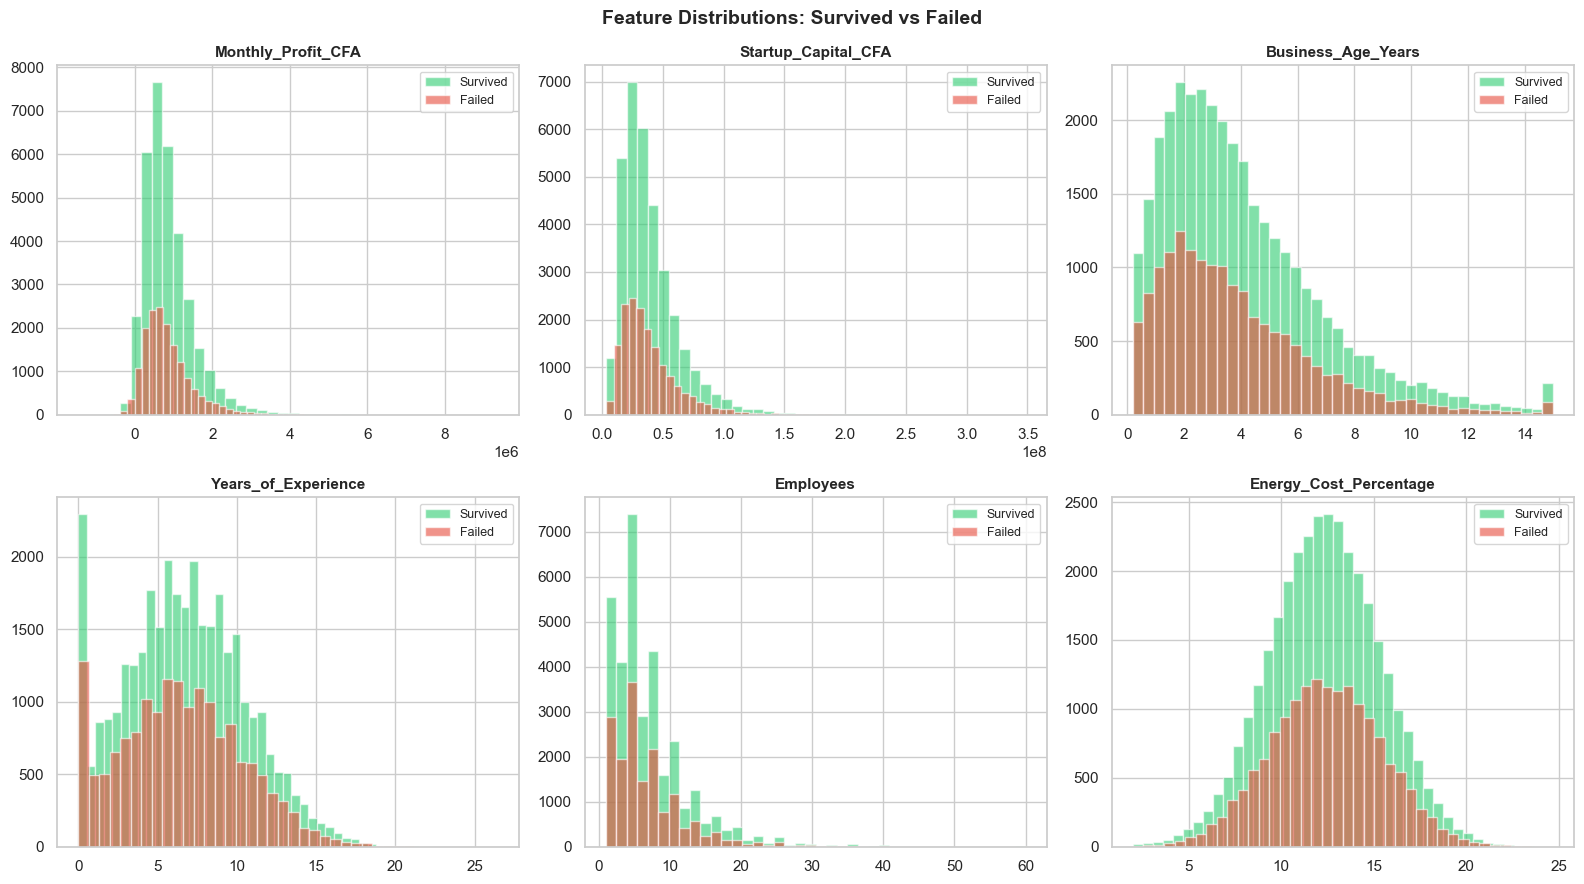

In [52]:
# --- Numeric Feature Distributions by Survival Outcome ---
# Pick the 6 most likely predictive numeric columns to visualise
key_numeric_cols = [
    'Monthly_Profit_CFA', 'Startup_Capital_CFA', 'Business_Age_Years',
    'Years_of_Experience', 'Employees', 'Energy_Cost_Percentage'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(key_numeric_cols):
    survived_vals = raw_df[raw_df['Survived_3_Years'] == 1][col]
    failed_vals   = raw_df[raw_df['Survived_3_Years'] == 0][col]

    axes[i].hist(survived_vals, bins=40, alpha=0.6, color='#2ecc71', label='Survived')
    axes[i].hist(failed_vals,   bins=40, alpha=0.6, color='#e74c3c', label='Failed')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=9)

plt.suptitle('Feature Distributions: Survived vs Failed', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 6 — Data Cleaning

**Design decision on `Monthly_Profit_CFA`:**  
The BizNess app assesses *existing* businesses (see `Business_Age_Years` column — businesses have a known age).  
Monthly profit is a known metric for any existing business, so it is **not leakage** in this context.  
If this model were used to score a brand-new business *before* it opens, this column would need to be removed.

In [53]:
# Work on a copy so the raw data stays untouched for reference
df = raw_df.copy()

# --- Drop columns that would leak future information into the model ---
# These were computed FROM the survival outcome, so keeping them would
# let the model 'see the answer' during training.
leaky_columns = [
    'Business_ID',                   # Identifier — carries no predictive signal
    'Survival_Probability_Simulated', # Directly derived from the target variable
    'Risk_Level_Simulated'            # Same as above
]
df = df.drop(columns=leaky_columns)
logger.info(f'Dropped leaky/identifier columns: {leaky_columns}')

# --- Fix the only column with missing values ---
# Owner_Education has ~6% missing — fill with 'Unknown' (a valid category)
missing_edu_count = df['Owner_Education'].isnull().sum()
df['Owner_Education'] = df['Owner_Education'].fillna('Unknown')
logger.info(f'Filled {missing_edu_count} missing values in Owner_Education with "Unknown"')

# --- Sanity check ---
print(f'Remaining columns : {df.shape[1]}')
print(f'Remaining rows    : {df.shape[0]:,}')
print(f'Missing values    : {df.isnull().sum().sum()}')
print('Data cleaning complete.')

2026-04-22 01:14:12,708 - INFO - Dropped leaky/identifier columns: ['Business_ID', 'Survival_Probability_Simulated', 'Risk_Level_Simulated']
2026-04-22 01:14:12,729 - INFO - Filled 3012 missing values in Owner_Education with "Unknown"


Remaining columns : 34
Remaining rows    : 50,000
Missing values    : 0
Data cleaning complete.


## Section 7 — Train / Test Split

We split the data **before** feature engineering to prevent any information from the test set influencing our feature design choices.

In [54]:
# Separate features from the target
X_all = df.drop(columns=['Survived_3_Years'])
y_all = df['Survived_3_Years']

# 80% train, 20% test — stratify keeps the 67/33 class ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_all
)

logger.info(f'Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}')

print(f'Training set : {X_train.shape[0]:,} businesses ({X_train.shape[1]} features)')
print(f'Test set     : {X_test.shape[0]:,} businesses ({X_test.shape[1]} features)')

2026-04-22 01:14:13,059 - INFO - Train size: 40,000 | Test size: 10,000


Training set : 40,000 businesses (33 features)
Test set     : 10,000 businesses (33 features)


## Section 8 — Feature Engineering with Validation

**FIX from v1:** In v1, 3 engineered features were added and the model got *worse* (dropped from ~65% to 57%).  
The features were saved anyway without checking if they helped.

**New approach:** We measure the cross-validation score **before and after** adding each feature.  
A feature is only kept if it moves the needle upward.

In [55]:
def add_engineered_features(dataframe):
    """
    Add candidate engineered features to a dataframe.
    All features are pure arithmetic — no leakage risk.

    Note: profit_on_capital is only added when Monthly_Profit_CFA is present
    in the dataframe. It is skipped silently for the regression task, where
    Monthly_Profit_CFA is the target and has already been removed.
    """
    df_out = dataframe.copy()

    # Combined cost burden: how much of revenue goes to overhead
    df_out['total_overhead_pct']    = (
        df_out['Transport_Cost_Percentage'] + df_out['Energy_Cost_Percentage']
    )

    # Capital efficiency: how much investment backs each employee
    df_out['capital_per_employee']  = (
        df_out['Startup_Capital_CFA'] / df_out['Employees'].replace(0, 1)
    )

    # Risk-experience ratio: riskier sectors need more experienced owners
    df_out['risk_per_experience']   = (
        df_out['Sector_Risk_Baseline'] / (df_out['Years_of_Experience'] + 1)
    )

    # Infrastructure quality weighted by energy cost
    df_out['infra_energy_pressure'] = (
        df_out['Region_Infrastructure_Index'] * df_out['Energy_Cost_Percentage']
    )

    # Profitability rate — only valid when Monthly_Profit_CFA is a feature
    # (not available in the regression dataset where it is the target)
    if 'Monthly_Profit_CFA' in df_out.columns:
        df_out['profit_on_capital'] = (
            df_out['Monthly_Profit_CFA'] / (df_out['Startup_Capital_CFA'] + 1)
        )

    return df_out


# List of candidate features to validate one by one
candidate_features = [
    'total_overhead_pct',
    'capital_per_employee',
    'risk_per_experience',
    'infra_energy_pressure',
    'profit_on_capital'   # Only created when Monthly_Profit_CFA is present
]

print('Feature engineering candidates defined. Validation will run in the next cell.')

Feature engineering candidates defined. Validation will run in the next cell.


In [56]:
# We need a lightweight model to measure whether each feature adds value.
# We use Logistic Regression here — fast, and a good neutral baseline.

# --- Baseline score (no engineered features) ---
baseline_num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
baseline_cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

baseline_pipeline = ImbPipeline(steps=[
    ('preprocess',  build_preprocessor(baseline_num_cols, baseline_cat_cols)),
    ('smote',       SMOTE(random_state=RANDOM_SEED)),
    ('model',       LogisticRegression(max_iter=500, random_state=RANDOM_SEED))
])

print('Measuring baseline CV accuracy (no engineered features)...')
# n_jobs=1 — loky multiprocessing cannot serialize ImbPipeline on Python 3.14
cv_scores_baseline = cross_val_score(
    baseline_pipeline, X_train, y_train,
    cv=CV_STRATEGY, scoring='accuracy', n_jobs=1
)
baseline_cv_acc = cv_scores_baseline.mean()
print(f'Baseline CV Accuracy (no engineered features): {baseline_cv_acc * 100:.2f}%\n')

# --- Test with ALL engineered candidates combined ---
X_train_with_features = add_engineered_features(X_train)

eng_num_cols = X_train_with_features.select_dtypes(include=['int64', 'float64']).columns.tolist()
eng_cat_cols = X_train_with_features.select_dtypes(include=['object', 'category']).columns.tolist()

engineered_pipeline = ImbPipeline(steps=[
    ('preprocess',  build_preprocessor(eng_num_cols, eng_cat_cols)),
    ('smote',       SMOTE(random_state=RANDOM_SEED)),
    ('model',       LogisticRegression(max_iter=500, random_state=RANDOM_SEED))
])

print('Measuring CV accuracy WITH engineered features...')
# n_jobs=1 — same reason as above
cv_scores_eng = cross_val_score(
    engineered_pipeline, X_train_with_features, y_train,
    cv=CV_STRATEGY, scoring='accuracy', n_jobs=1
)
engineered_cv_acc = cv_scores_eng.mean()
print(f'CV Accuracy WITH engineered features: {engineered_cv_acc * 100:.2f}%\n')

# --- Decision: only keep features if they actually help ---
improvement = engineered_cv_acc - baseline_cv_acc
if improvement > 0:
    USE_ENGINEERED_FEATURES = True
    print(f'VERDICT: Engineered features IMPROVE accuracy by {improvement * 100:.2f}%. Keeping them.')
else:
    USE_ENGINEERED_FEATURES = False
    print(f'VERDICT: Engineered features HURT accuracy by {abs(improvement) * 100:.2f}%. Discarding them.')

logger.info(f'Feature engineering — Baseline: {baseline_cv_acc:.4f} | Engineered: {engineered_cv_acc:.4f} | Keep: {USE_ENGINEERED_FEATURES}')

Measuring baseline CV accuracy (no engineered features)...
Baseline CV Accuracy (no engineered features): 55.05%

Measuring CV accuracy WITH engineered features...


2026-04-22 01:14:38,463 - INFO - Feature engineering — Baseline: 0.5505 | Engineered: 0.5512 | Keep: True


CV Accuracy WITH engineered features: 55.12%

VERDICT: Engineered features IMPROVE accuracy by 0.07%. Keeping them.


In [57]:
# Apply the decision from the validation step
if USE_ENGINEERED_FEATURES:
    X_train_final = add_engineered_features(X_train)
    X_test_final  = add_engineered_features(X_test)
    print('Using engineered features for training.')
else:
    X_train_final = X_train.copy()
    X_test_final  = X_test.copy()
    print('Using original features only.')

# Identify column types for the final dataset
final_num_cols = X_train_final.select_dtypes(include=['int64', 'float64']).columns.tolist()
final_cat_cols = X_train_final.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Final feature count — Numeric: {len(final_num_cols)} | Categorical: {len(final_cat_cols)}')

Using engineered features for training.
Final feature count — Numeric: 24 | Categorical: 14


## Section 9 — Model Comparison with Cross-Validation

**FIX from v1:**  
- v1 used a single train/test split to compare models — that split can be lucky or unlucky.  
- v1 mixed SMOTE (for some models) with `class_weight='balanced'` (for others) making comparison unfair.  

**New approach:**  
- All models use SMOTE (accuracy-focused, consistent balancing strategy).  
- All models are scored with 5-fold stratified cross-validation on the same data.  
- The top 2 scorers go forward to hyperparameter tuning.

In [58]:
# Build the shared preprocessor once — same for all classifiers
shared_preprocessor = build_preprocessor(final_num_cols, final_cat_cols)

# --- Define all candidate classifiers ---
# Each model is wrapped in an ImbPipeline that includes SMOTE.
# 'verbose=0' on CatBoost silences its 1000-line training log.
candidate_classifiers = {

    'Logistic Regression (Baseline)': ImbPipeline(steps=[
        ('preprocess', build_preprocessor(final_num_cols, final_cat_cols)),
        ('smote',      SMOTE(random_state=RANDOM_SEED)),
        ('model',      LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))
    ]),

    'Random Forest': ImbPipeline(steps=[
        ('preprocess', build_preprocessor(final_num_cols, final_cat_cols)),
        ('smote',      SMOTE(random_state=RANDOM_SEED)),
        ('model',      RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_SEED))
    ]),

    'XGBoost': ImbPipeline(steps=[
        ('preprocess', build_preprocessor(final_num_cols, final_cat_cols)),
        ('smote',      SMOTE(random_state=RANDOM_SEED)),
        ('model',      XGBClassifier(n_estimators=100, learning_rate=0.1,
                                     eval_metric='logloss', random_state=RANDOM_SEED))
    ]),

    'LightGBM': ImbPipeline(steps=[
        ('preprocess', build_preprocessor(final_num_cols, final_cat_cols)),
        ('smote',      SMOTE(random_state=RANDOM_SEED)),
        ('model',      LGBMClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_SEED))
    ]),

    'CatBoost': ImbPipeline(steps=[
        ('preprocess', build_preprocessor(final_num_cols, final_cat_cols)),
        ('smote',      SMOTE(random_state=RANDOM_SEED)),
        ('model',      CatBoostClassifier(iterations=100, random_state=RANDOM_SEED, verbose=0))
    ]),
}

# --- Run cross-validation for every candidate ---
print('Running 5-fold CV for all candidate models...')
print('-' * 60)

cv_results = {}  # Store mean CV accuracy for each model

for model_name, pipeline in candidate_classifiers.items():
    mean_acc = cross_validate_classifier(pipeline, X_train_final, y_train, model_name)
    cv_results[model_name] = mean_acc

# --- Rank the models ---
print('\n' + '='*60)
print('  MODEL RANKING (by CV Accuracy)')
print('='*60)

ranked = sorted(cv_results.items(), key=lambda x: x[1], reverse=True)
for rank, (name, acc) in enumerate(ranked, start=1):
    marker = '  <-- TOP 2, will tune' if rank <= 2 else ''
    print(f'  {rank}. {name:<40} {acc * 100:.2f}%{marker}')

# Pick the top 2 for hyperparameter tuning
top_two_model_names = [ranked[0][0], ranked[1][0]]
logger.info(f'Model comparison done. Top 2: {top_two_model_names}')

Running 5-fold CV for all candidate models...
------------------------------------------------------------
  Running 5-fold CV for: Logistic Regression (Baseline) ... Done.  Mean Accuracy: 55.12% (+/- 0.48%)
  Running 5-fold CV for: Random Forest ... Done.  Mean Accuracy: 66.25% (+/- 0.18%)
  Running 5-fold CV for: XGBoost ... Done.  Mean Accuracy: 66.83% (+/- 0.19%)
  Running 5-fold CV for: LightGBM ... [LightGBM] [Info] Number of positive: 21467, number of negative: 21467
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044328 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 26768
[LightGBM] [Info] Number of data points in the train set: 42934, number of used features: 114
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 21467, number of negative: 21467
[LightGBM] [Info

2026-04-22 01:18:23,412 - INFO - Model comparison done. Top 2: ['LightGBM', 'XGBoost']


Done.  Mean Accuracy: 65.08% (+/- 0.27%)

  MODEL RANKING (by CV Accuracy)
  1. LightGBM                                 66.89%  <-- TOP 2, will tune
  2. XGBoost                                  66.83%  <-- TOP 2, will tune
  3. Random Forest                            66.25%
  4. CatBoost                                 65.08%
  5. Logistic Regression (Baseline)           55.12%


## Section 10 — Hyperparameter Tuning on Top 2 Models

**FIX from v1:** `GridSearchCV` was imported but never used.

We use `RandomizedSearchCV` instead of `GridSearchCV` because:
- The dataset is large (40k training rows)
- Random search finds good results faster by sampling the parameter space
- `n_iter=30` tries 30 random combinations — usually finds 90%+ of what a full grid would find

In [59]:
# --- Hyperparameter grids for the models most likely to be in the top 2 ---
# Only the relevant grid will be used depending on which models won.

param_grids = {

    'XGBoost': {
        'model__n_estimators':     [200, 300, 500],
        'model__learning_rate':    [0.01, 0.05, 0.1],
        'model__max_depth':        [4, 6, 8],
        'model__subsample':        [0.7, 0.8, 1.0],
        'model__colsample_bytree': [0.7, 0.8, 1.0]
    },

    'LightGBM': {
        'model__n_estimators':       [200, 300, 500],
        'model__learning_rate':      [0.01, 0.05, 0.1],
        'model__num_leaves':         [31, 50, 100],
        'model__max_depth':          [-1, 6, 10],
        'model__min_child_samples':  [20, 50, 100]
    },

    'CatBoost': {
        'model__iterations':    [200, 400, 600],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__depth':         [4, 6, 8],
        'model__l2_leaf_reg':   [1, 3, 5, 10]
    },

    'Random Forest': {
        'model__n_estimators':      [100, 200, 300],
        'model__max_depth':         [None, 10, 20, 30],
        'model__min_samples_split': [2, 5, 10],
        'model__max_features':      ['sqrt', 'log2']
    },

    'Logistic Regression (Baseline)': {
        'model__C':      [0.01, 0.1, 1, 10],
        'model__solver': ['lbfgs', 'saga']
    }
}


def tune_model(model_name, pipeline, X_train_data, y_train_data, n_iter=30):
    """
    Run RandomizedSearchCV on a pipeline and return the best tuned version.

    NOTE: n_jobs=1 is intentional — joblib's loky backend cannot serialize
    ImbPipeline objects on Python 3.14. Single-threaded search still works
    correctly; it's just slower than parallel.
    """
    if model_name not in param_grids:
        print(f'  No param grid defined for {model_name}. Returning untuned pipeline.')
        return pipeline, None

    print(f'\nTuning: {model_name}  ({n_iter} random combinations x 5-fold CV)...')

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grids[model_name],
        n_iter=n_iter,
        scoring='accuracy',
        cv=CV_STRATEGY,
        n_jobs=1,             # n_jobs=1 — do NOT change to -1, see docstring
        random_state=RANDOM_SEED,
        verbose=1
    )

    search.fit(X_train_data, y_train_data)

    print(f'  Best CV Accuracy : {search.best_score_ * 100:.2f}%')
    print(f'  Best Params      : {search.best_params_}')
    logger.info(f'Tuning {model_name} — Best CV Acc: {search.best_score_:.4f} | Params: {search.best_params_}')

    return search.best_estimator_, search.best_score_


print(f'Tuning helpers ready. Will tune: {top_two_model_names}')

Tuning helpers ready. Will tune: ['LightGBM', 'XGBoost']


In [60]:
# Run tuning on the two best performers from cross-validation
tuned_models = {}

for model_name in top_two_model_names:
    original_pipeline = candidate_classifiers[model_name]
    best_pipeline, best_score = tune_model(
        model_name, original_pipeline, X_train_final, y_train
    )
    tuned_models[model_name] = {'pipeline': best_pipeline, 'cv_score': best_score}

# Pick the overall winner: the tuned model with the highest CV accuracy
best_model_name = max(tuned_models, key=lambda k: tuned_models[k]['cv_score'])
best_pipeline   = tuned_models[best_model_name]['pipeline']
best_cv_score   = tuned_models[best_model_name]['cv_score']
  
print(f'\n{"="*60}')
print(f'  WINNER: {best_model_name}')
print(f'  Best CV Accuracy: {best_cv_score * 100:.2f}%')
print(f'{"="*60}')

logger.info(f'Best overall model: {best_model_name} | CV Accuracy: {best_cv_score:.4f}')


Tuning: LightGBM  (30 random combinations x 5-fold CV)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
[LightGBM] [Info] Number of positive: 21467, number of negative: 21467
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.047474 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 26768
[LightGBM] [Info] Number of data points in the train set: 42934, number of used features: 114
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 21467, number of negative: 21467
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.132440 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26754
[LightGBM] [Info] Number of data points in the train set: 42934, number of used features: 114
[LightGBM] [

2026-04-22 02:15:44,589 - INFO - Tuning LightGBM — Best CV Acc: 0.6709 | Params: {'model__num_leaves': 31, 'model__n_estimators': 200, 'model__min_child_samples': 50, 'model__max_depth': -1, 'model__learning_rate': 0.01}


  Best CV Accuracy : 67.09%
  Best Params      : {'model__num_leaves': 31, 'model__n_estimators': 200, 'model__min_child_samples': 50, 'model__max_depth': -1, 'model__learning_rate': 0.01}

Tuning: XGBoost  (30 random combinations x 5-fold CV)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


2026-04-22 03:12:20,031 - INFO - Tuning XGBoost — Best CV Acc: 0.6708 | Params: {'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 4, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.8}
2026-04-22 03:12:20,112 - INFO - Best overall model: LightGBM | CV Accuracy: 0.6709


  Best CV Accuracy : 67.08%
  Best Params      : {'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 4, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.8}

  WINNER: LightGBM
  Best CV Accuracy: 67.09%


## Section 11 — Final Model Evaluation on the Hold-Out Test Set

This is the first time the best model sees the test set.  
We use the `evaluate_classifier` helper to keep it consistent and reproducible.

Evaluating final model on 10,000 unseen test records...

  RESULTS: LightGBM (Tuned)
  Accuracy  : 67.09%
  Precision : 58.55%
  Recall    : 50.01%
  F1-Score  : 40.18%
-------------------------------------------------------
              precision    recall  f1-score   support

  Failed (0)       0.50      0.00      0.00      3291
Survived (1)       0.67      1.00      0.80      6709

    accuracy                           0.67     10000
   macro avg       0.59      0.50      0.40     10000
weighted avg       0.61      0.67      0.54     10000



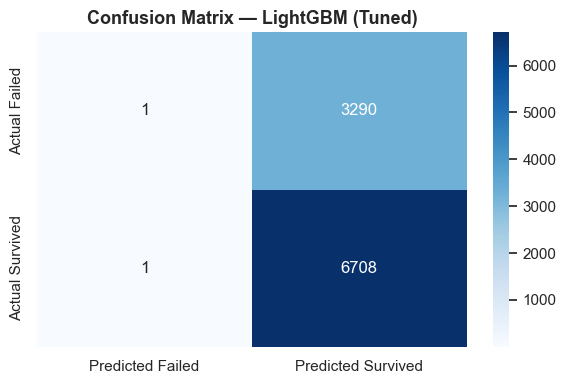

2026-04-22 03:12:21,407 - INFO - Final Test Results — Accuracy: 0.6709 | F1: 0.4018


In [61]:
# Re-fit the best pipeline on the full training set before evaluating
# (RandomizedSearchCV already does this internally, so best_pipeline is ready)

print(f'Evaluating final model on {X_test_final.shape[0]:,} unseen test records...')

final_metrics = evaluate_classifier(
    best_pipeline,
    X_test_final,
    y_test,
    model_name=f'{best_model_name} (Tuned)',
    cmap='Blues'
)

logger.info(
    f'Final Test Results — '
    f'Accuracy: {final_metrics["accuracy"]:.4f} | '
    f'F1: {final_metrics["f1"]:.4f}'
)

## Section 12 — Threshold Analysis on the Final Model

**FIX from v1:** Threshold analysis was run on a *different* model than what got saved.  
Now it runs directly on `best_pipeline` — the exact model we will save to production.

The threshold controls the risk trade-off:
- **Lower threshold** → catch more failing businesses (safer for the user)
- **Higher threshold** → fewer false alarms but may miss real failures

Threshold Analysis on the FINAL SAVED MODEL
 Threshold    Accuracy   Recall-Failed   Recall-Survived
-----------------------------------------------------------------
       35%      67.09%           0.00%           100.00%
       40%      67.09%           0.00%           100.00%
       45%      67.09%           0.00%           100.00%
       50%      67.09%           0.03%            99.99%
       55%      66.16%           8.60%            94.40%
       60%      59.70%          39.53%            69.59%
TIP: For a risk-advisory tool, lower threshold = more conservative = safer.


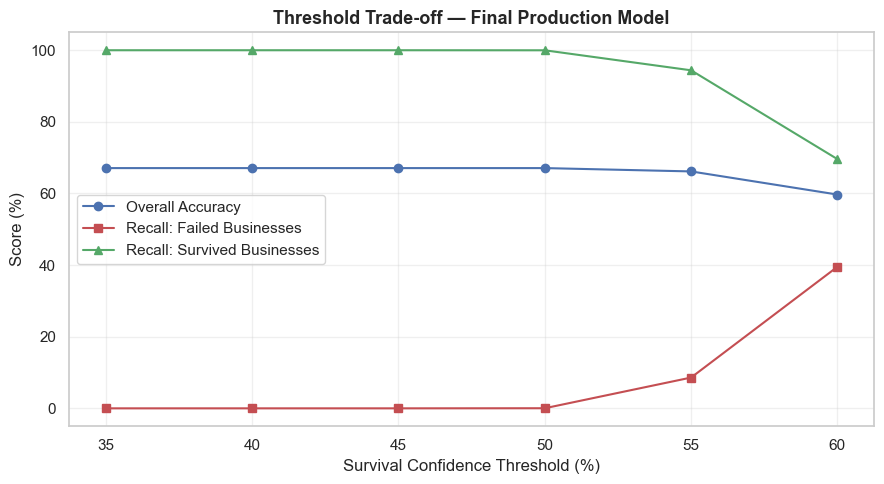

In [62]:
# Get survival probabilities from the final model
# predict_proba returns [[P(fail), P(survive)], ...] for each business
survival_probabilities = best_pipeline.predict_proba(X_test_final)[:, 1]

# Thresholds to test: what confidence level does a business need to be called 'likely to survive'?
thresholds = [0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

threshold_results = []

print('Threshold Analysis on the FINAL SAVED MODEL')
print('='*65)
print(f'{"Threshold":>10}  {"Accuracy":>10}  {"Recall-Failed":>14}  {"Recall-Survived":>16}')
print('-'*65)

for threshold in thresholds:
    # Apply custom threshold: only call a business 'survived' if confidence >= threshold
    custom_preds = (survival_probabilities >= threshold).astype(int)

    acc           = accuracy_score(y_test, custom_preds)
    recall_failed   = recall_score(y_test, custom_preds, pos_label=0)
    recall_survived = recall_score(y_test, custom_preds, pos_label=1)

    print(f'{threshold * 100:>9.0f}%  {acc * 100:>9.2f}%  {recall_failed * 100:>13.2f}%  {recall_survived * 100:>15.2f}%')

    threshold_results.append({
        'threshold':        threshold,
        'accuracy':         acc,
        'recall_failed':    recall_failed,
        'recall_survived':  recall_survived
    })

print('='*65)
print('TIP: For a risk-advisory tool, lower threshold = more conservative = safer.')

# Plot threshold vs. recall trade-off
results_df = pd.DataFrame(threshold_results)

plt.figure(figsize=(9, 5))
plt.plot(results_df['threshold'] * 100, results_df['accuracy']      * 100, 'b-o', label='Overall Accuracy')
plt.plot(results_df['threshold'] * 100, results_df['recall_failed']  * 100, 'r-s', label='Recall: Failed Businesses')
plt.plot(results_df['threshold'] * 100, results_df['recall_survived']* 100, 'g-^', label='Recall: Survived Businesses')
plt.xlabel('Survival Confidence Threshold (%)', fontsize=12)
plt.ylabel('Score (%)', fontsize=12)
plt.title('Threshold Trade-off — Final Production Model', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 13 — Feature Importance

Understand which features drive the model's decisions — useful for product insights.

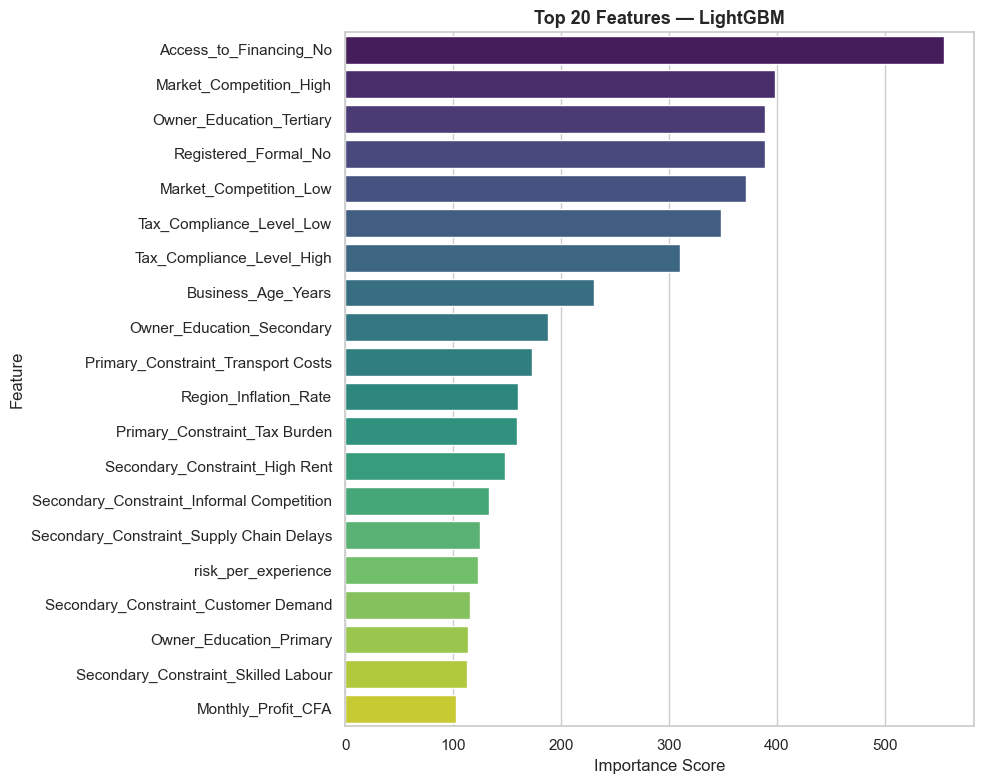


Top 10 Features:
                           feature  importance
            Access_to_Financing_No         555
           Market_Competition_High         398
          Owner_Education_Tertiary         389
              Registered_Formal_No         389
            Market_Competition_Low         371
          Tax_Compliance_Level_Low         348
         Tax_Compliance_Level_High         310
                Business_Age_Years         231
         Owner_Education_Secondary         188
Primary_Constraint_Transport Costs         173


In [63]:
# Extract the trained classifier from the pipeline
trained_classifier = best_pipeline.named_steps['model']

# Get all feature names as the preprocessor sees them after encoding
preprocessor_step = best_pipeline.named_steps['preprocess']
encoded_feature_names = preprocessor_step.get_feature_names_out()

# Retrieve importance scores — works for tree-based models (RF, XGB, LGBM, CatBoost)
try:
    if hasattr(trained_classifier, 'feature_importances_'):
        importance_scores = trained_classifier.feature_importances_
    elif hasattr(trained_classifier, 'get_feature_importance'):
        importance_scores = trained_classifier.get_feature_importance()  # CatBoost
    else:
        print('Feature importance not available for this model type.')
        importance_scores = None

    if importance_scores is not None:
        # Build a clean dataframe
        importance_df = pd.DataFrame({
            'feature':    encoded_feature_names,
            'importance': importance_scores
        })

        # Clean up the prefix labels added by ColumnTransformer
        importance_df['feature'] = (
            importance_df['feature']
            .str.replace('numeric__',     '', regex=False)
            .str.replace('categorical__', '', regex=False)
        )

        importance_df = importance_df.sort_values('importance', ascending=False)

        # Plot top 20
        top_n = 20
        plt.figure(figsize=(10, 8))
        sns.barplot(
            data=importance_df.head(top_n),
            x='importance', y='feature',
            palette='viridis'
        )
        plt.title(f'Top {top_n} Features — {best_model_name}', fontsize=13, fontweight='bold')
        plt.xlabel('Importance Score')
        plt.ylabel('Feature')
        plt.tight_layout()
        plt.show()

        print(f'\nTop 10 Features:')
        print(importance_df.head(10).to_string(index=False))

except Exception as e:
    print(f'Could not extract feature importance: {e}')

## Section 14 — Save the Survival Classification Model

In [64]:
os.makedirs('backend/models', exist_ok=True)

# Save paths
classifier_path   = 'backend/models/sme_survival_model_v2.pkl'
feature_list_path = 'backend/models/survival_feature_list_v2.pkl'

# Save the full pipeline (preprocessor + SMOTE + trained model)
joblib.dump(best_pipeline, classifier_path)

# Save the exact column list the model expects — critical for the FastAPI endpoint
joblib.dump(X_train_final.columns.tolist(), feature_list_path)

logger.info(f'Survival model saved: {classifier_path}')
logger.info(f'Feature list saved  : {feature_list_path}')

print(f'Classifier saved to : {classifier_path}')
print(f'Feature list saved  : {feature_list_path}')
print(f'Final Test Accuracy : {final_metrics["accuracy"] * 100:.2f}%')

2026-04-22 03:12:23,446 - INFO - Survival model saved: backend/models/sme_survival_model_v2.pkl
2026-04-22 03:12:23,449 - INFO - Feature list saved  : backend/models/survival_feature_list_v2.pkl


Classifier saved to : backend/models/sme_survival_model_v2.pkl
Feature list saved  : backend/models/survival_feature_list_v2.pkl
Final Test Accuracy : 67.09%


## Section 15 — Profit Forecasting Model (Regression)

Separate task: predict `Monthly_Profit_CFA` as a continuous number.  
This uses XGBoost Regressor with hyperparameter tuning.

In [65]:
# --- Prepare Regression Data ---
# Drop both the profit target AND the survival column.
# Survival outcome is not known at prediction time for the regression task.
reg_feature_cols = [c for c in df.columns if c not in ['Monthly_Profit_CFA', 'Survived_3_Years']]

X_reg = df[reg_feature_cols]
y_reg = df['Monthly_Profit_CFA']

# Apply the same feature engineering decision as the classifier.
# add_engineered_features will skip profit_on_capital automatically because
# Monthly_Profit_CFA is not in X_reg (it's the target here).
if USE_ENGINEERED_FEATURES:
    X_reg = add_engineered_features(X_reg)
    print('Applied engineered features to regression dataset.')

# Standard 80/20 split (no stratify needed for regression)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_SEED
)

# Identify column types for the regression dataset
reg_num_cols = X_train_reg.select_dtypes(include=['int64', 'float64']).columns.tolist()
reg_cat_cols = X_train_reg.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Regression features — Numeric: {len(reg_num_cols)} | Categorical: {len(reg_cat_cols)}')
print(f'Train rows: {X_train_reg.shape[0]:,} | Test rows: {X_test_reg.shape[0]:,}')

Applied engineered features to regression dataset.
Regression features — Numeric: 22 | Categorical: 14
Train rows: 40,000 | Test rows: 10,000


Training XGBoost Profit Regressor...


2026-04-22 03:12:35,290 - INFO - Profit Regressor — R2: 0.4951 | MAE: 323,371 CFA


Training complete.

  PROFIT FORECASTING RESULTS: XGBoost Regressor
  R-Squared (R2) : 49.51%  (variance explained)
  MAE            :      323,371 CFA (avg prediction error)


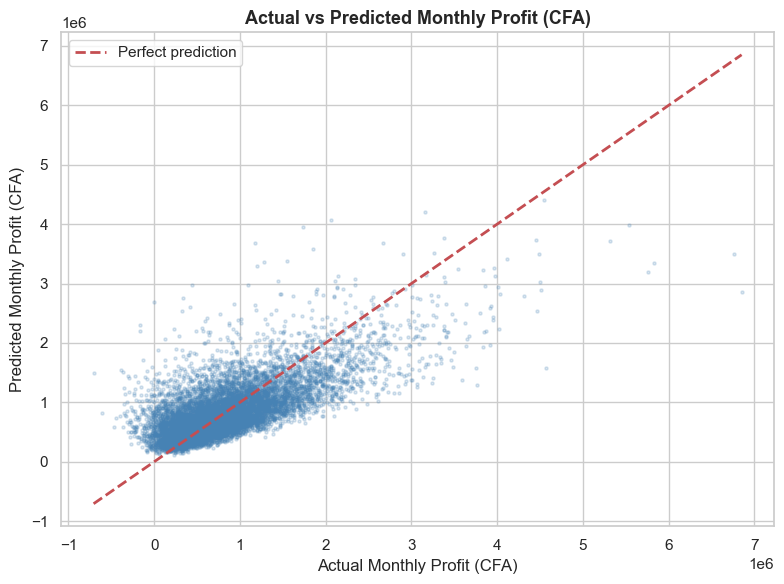

In [66]:
# --- Build XGBoost Regression Pipeline ---
# Note: No SMOTE here — SMOTE is only for classification (class imbalance).
# Regression does not have class imbalance.
xgb_regressor_pipeline = Pipeline(steps=[
    ('preprocess', build_preprocessor(reg_num_cols, reg_cat_cols)),
    ('model',      XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        random_state=RANDOM_SEED
    ))
])

print('Training XGBoost Profit Regressor...')
xgb_regressor_pipeline.fit(X_train_reg, y_train_reg)
print('Training complete.')

# --- Evaluate ---
profit_predictions = xgb_regressor_pipeline.predict(X_test_reg)

r2  = r2_score(y_test_reg, profit_predictions)
mae = mean_absolute_error(y_test_reg, profit_predictions)

logger.info(f'Profit Regressor — R2: {r2:.4f} | MAE: {mae:,.0f} CFA')

print(f'\n{"="*55}')
print(f'  PROFIT FORECASTING RESULTS: XGBoost Regressor')
print(f'{"="*55}')
print(f'  R-Squared (R2) : {r2 * 100:.2f}%  (variance explained)')
print(f'  MAE            : {mae:>12,.0f} CFA (avg prediction error)')
print(f'{"="*55}')

# --- Visualise Actual vs Predicted ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, profit_predictions, alpha=0.2, color='steelblue', s=5)

# Perfect prediction line (45-degree diagonal)
min_val = min(y_test_reg.min(), profit_predictions.min())
max_val = max(y_test_reg.max(), profit_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')

plt.title('Actual vs Predicted Monthly Profit (CFA)', fontsize=13, fontweight='bold')
plt.xlabel('Actual Monthly Profit (CFA)')
plt.ylabel('Predicted Monthly Profit (CFA)')
plt.legend()
plt.tight_layout()
plt.show()

## Section 16 — Save the Profit Regression Model

In [67]:
regressor_path       = 'backend/models/sme_profit_model_v2.pkl'
reg_feature_list_path = 'backend/models/profit_feature_list_v2.pkl'

# Save the regression pipeline
joblib.dump(xgb_regressor_pipeline, regressor_path)

# Save the exact column list for the FastAPI profit endpoint
joblib.dump(X_train_reg.columns.tolist(), reg_feature_list_path)

logger.info(f'Profit model saved  : {regressor_path}')
logger.info(f'Feature list saved  : {reg_feature_list_path}')

print(f'Profit model saved  : {regressor_path}')
print(f'Feature list saved  : {reg_feature_list_path}')

2026-04-22 03:12:35,827 - INFO - Profit model saved  : backend/models/sme_profit_model_v2.pkl
2026-04-22 03:12:35,829 - INFO - Feature list saved  : backend/models/profit_feature_list_v2.pkl


Profit model saved  : backend/models/sme_profit_model_v2.pkl
Feature list saved  : backend/models/profit_feature_list_v2.pkl


## Section 17 — Summary

All models trained and saved. Below is a final summary of what was produced.

In [68]:
print('=' * 65)
print('  BIZNESS ML PIPELINE v2 — FINAL SUMMARY')
print('=' * 65)

print(f'\n  SURVIVAL CLASSIFIER')
print(f'  Winner model     : {best_model_name}')
print(f'  CV Accuracy      : {best_cv_score * 100:.2f}%')
print(f'  Test Accuracy    : {final_metrics["accuracy"] * 100:.2f}%')
print(f'  Test F1 (macro)  : {final_metrics["f1"] * 100:.2f}%')
print(f'  Saved to         : {classifier_path}')

print(f'\n  PROFIT REGRESSOR')
print(f'  Model            : XGBoost Regressor')
print(f'  Test R2          : {r2 * 100:.2f}%')
print(f'  Test MAE         : {mae:,.0f} CFA')
print(f'  Saved to         : {regressor_path}')

print(f'\n  FEATURE ENGINEERING')
print(f'  Used             : {USE_ENGINEERED_FEATURES}')

print('\n' + '=' * 65)
logger.info('Pipeline v2 complete. All models saved.')

2026-04-22 03:12:35,862 - INFO - Pipeline v2 complete. All models saved.


  BIZNESS ML PIPELINE v2 — FINAL SUMMARY

  SURVIVAL CLASSIFIER
  Winner model     : LightGBM
  CV Accuracy      : 67.09%
  Test Accuracy    : 67.09%
  Test F1 (macro)  : 40.18%
  Saved to         : backend/models/sme_survival_model_v2.pkl

  PROFIT REGRESSOR
  Model            : XGBoost Regressor
  Test R2          : 49.51%
  Test MAE         : 323,371 CFA
  Saved to         : backend/models/sme_profit_model_v2.pkl

  FEATURE ENGINEERING
  Used             : True

